In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
data = pd.read_csv("../STOCK MARKET/IOC.csv")
data.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,IOC,EQ,254.00,260.0,273.25,250.00,267.35,270.85,258.55,23700,6.127648e+11,NaN,NaN,NaN
1,2000-01-04,IOC,EQ,270.85,260.0,268.00,254.10,267.00,264.40,259.80,24400,6.339112e+11,NaN,NaN,NaN
2,2000-01-05,IOC,EQ,264.40,264.9,265.00,257.00,261.35,261.30,260.66,18900,4.926382e+11,NaN,NaN,NaN
3,2000-01-06,IOC,EQ,261.30,258.0,263.00,256.05,263.00,260.10,259.81,18150,4.715515e+11,NaN,NaN,NaN
4,2000-01-07,IOC,EQ,260.10,259.9,267.00,253.25,267.00,264.45,260.11,17650,4.590902e+11,NaN,NaN,NaN


In [12]:
tesla_data = yf.download("TSLA",start="2024-01-01",end="2025-02-01")
tesla_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2024-01-02,248.419998,251.250000,244.410004,250.080002,104654200
2024-01-03,238.449997,245.679993,236.320007,244.979996,121082600
2024-01-04,237.929993,242.699997,237.729996,239.250000,102629300
2024-01-05,237.490005,240.119995,234.899994,236.860001,92379400
2024-01-08,240.449997,241.250000,235.300003,236.139999,85166600


In [13]:
df = tesla_data
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,272.000000,272.000000,272.000000,272.000000,2.720000e+02
mean,243.438787,248.802353,237.954485,243.466655,9.341493e+07
std,82.212197,84.758367,79.444089,82.415749,3.277676e+07
min,142.050003,144.440002,138.800003,140.559998,3.716760e+07
25%,181.475006,185.697502,177.982498,182.857502,7.008125e+07
50%,216.195000,220.979996,212.144997,216.975006,8.614850e+07
75%,257.152489,262.427498,250.607502,256.352509,1.086079e+08
max,479.859985,488.540009,457.510010,475.899994,2.438697e+08


In [19]:
df = df.reset_index()

In [20]:
df.isnull().sum()

Price   Ticker
Date              0
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

In [21]:
data = df


In [23]:
from sklearn.preprocessing import MinMaxScaler
df = data[['Close']]
scaler = MinMaxScaler(feature_range=(0,1))
s_df = scaler.fit_transform(df)

In [24]:
def create_sequences(data,time_steps=60):
    x,y = [],[]
    for i in range(len(data)-time_steps):
        x.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(x),np.array(y)

In [25]:
time_steps = 60
x,y = create_sequences(s_df,time_steps)
train_size = int(len(x)*0.8)
x_train,x_test = x[:train_size],x[train_size:]
y_train,y_test = y[:train_size],y[train_size:]

x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
x_test = np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
import warnings
warnings.filterwarnings("ignore")

In [33]:


model = Sequential([
    LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1],1)),
    LSTM(units=50,return_sequences=False),
    Dense(units=50),
    Dense(units=1)
])

model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,201 (129.69 KB)

 Trainable params: 33,201 (129.69 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.fit(x_train,y_train,epochs=50,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - loss: 0.0462 - val_loss: 0.0132
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0121 - val_loss: 0.0496
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0071 - val_loss: 0.0521
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0068 - val_loss: 0.0096
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0055 - val_loss: 0.0117
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0051 - val_loss: 0.0104
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0035 - val_loss: 0.0321
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 0.0039 - val_loss: 0.0152
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0036 - val_loss: 0.0185
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0033 - val_loss: 0.0155
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - loss: 0.0033 - val_loss: 0.0119
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - loss: 0.0032 - val_loss: 0.0

In [35]:
predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step


In [37]:
predicted_prices.shape,y_test_actual.shape

((43, 1), (43, 1))

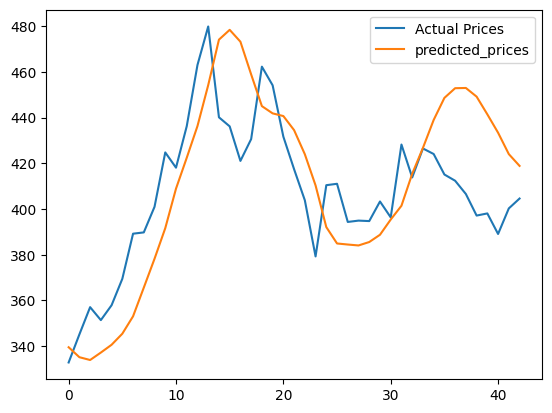

In [39]:
plt.plot(y_test_actual,label='Actual Prices')
plt.plot(predicted_prices,label="predicted_prices")
plt.legend()

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_actual, predicted_prices))
print("Test R2:", r2)


Test RMSE: 26.5238134673503
